<a href="https://colab.research.google.com/github/Alexd17d/EXAM-B1/blob/main/EXAM_B1_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
plt.style.use('dark_background')


df = pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')

           CONTEO DE PERSONAL           
----------------------------------------
Total de la Plantilla:      1470 colaboradores
Bajas Registradas:           237 profesionales
----------------------------------------
Tasa de Deserción:        16.12%
----------------------------------------
--------------------------------------------------------------------------------


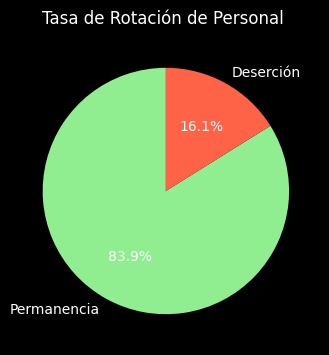

In [47]:
#KPI 1: Cálculo matemático
total_empleados = len(df)
total_empleados = len(df)
empleados_salieron = len(df[df['Attrition'] == 'Yes'])
attrition_rate = (empleados_salieron / total_empleados) * 100

print(f"{' CONTEO DE PERSONAL ':^40}")
print("-" * 40)
print(f"Total de la Plantilla:  {total_empleados:>8} colaboradores")
print(f"Bajas Registradas:      {empleados_salieron:>8} profesionales")
print("-" * 40)
print(f"Tasa de Deserción:      {attrition_rate:>7.2f}%")
print("-" * 40)

# KPI 1: Attrition Rate
print("-" * 80)
conteo_attrition = df['Attrition'].value_counts()
plt.figure(figsize=(6, 4))
plt.pie(conteo_attrition, labels=['Permanencia', 'Deserción'], autopct='%1.1f%%', colors=['lightgreen', 'tomato'], startangle=90)
plt.title('Tasa de Rotación de Personal ', fontsize=12, pad=10)
plt.show()

### Conclusión KPI 1: Attrition Rate
* La empresa presenta una tasa de deserción del **16.1%**, lo que equivale a la baja de **237** profesionales sobre la plantilla total de **1470**.
Este valor actúa como una señal de alerta crítica para la gobernanza corporativa; supera los estándares óptimos de retención y demanda estrategias inmediatas para mitigar los altos costos asociados al reclutamiento y capacitación de nuevo personal.

       ESTRUCTURA SALARIAL POR DEPARTAMENTO       
• Sales                       $    6,959.17
• Human Resources             $    6,654.51
• Research & Development      $    6,281.25
--------------------------------------------------------------------------------


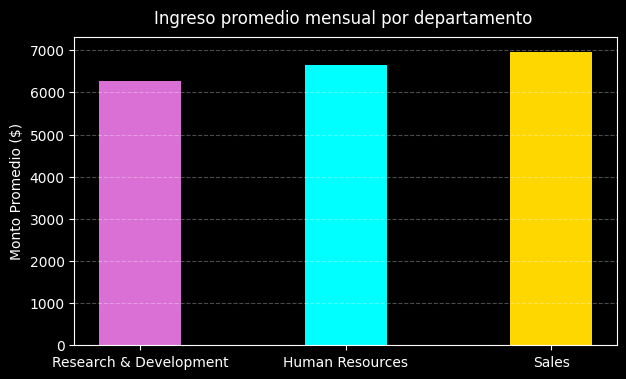

In [50]:
#KPI 2: Cálculo matemático
kpi_2 = df.groupby('Department')['MonthlyIncome'].mean().reset_index()
kpi_2.columns = ['Departamento', 'Ingreso Promedio']

# Ordenar de mayor a menor beneficio
kpi_2 = kpi_2.sort_values(by='Ingreso Promedio', ascending=False)

print(f"{' ESTRUCTURA SALARIAL POR DEPARTAMENTO ':^50}")
print("=" * 50)
for _, fila in kpi_2.iterrows():
    print(f"• {fila['Departamento']:<25}   ${fila['Ingreso Promedio']:>12,.2f}")
print("=" * 50)

#KPI 2 Ingreso promedio mensual por departamento
print("-" * 80)
ingreso_depto = df.groupby("Department")["MonthlyIncome"].mean().sort_values(ascending=True)
plt.figure(figsize=(7, 4))
plt.bar(ingreso_depto.index, ingreso_depto.values, color=['orchid', 'cyan', 'gold'], width=0.4)
plt.title("Ingreso promedio mensual por departamento ", fontsize=12, pad=10)
plt.ylabel("Monto Promedio ($)")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

### Conclusión KPI 2: Ingreso Promedio Mensual por Departamento
* El departamento de Ventas Sales registra la compensación medida más alta con (6,959.17 dolares), despues de ella continua Recursos humanos con (6,654,51 dolares), mientras que Investigación y Desarrollo R&D presenta el promedio más bajo con (6,281.25 dolares),este indicador analiza las estructuras de compensación del HRIS, descubriendo discrepancias salariales estadísticas entre departamentos que necesitan ser examinadas para garantizar la equidad interna.



         ÍNDICE WORK-LIFE BALANCE (ESCALA 1-4)         
-------------------------------------------------------
- Research Scientist               2.68  
- Healthcare Representative        2.70  
- Laboratory Technician            2.72  
- Manufacturing Director           2.77  
- Manager                          2.77  
- Sales Executive                  2.80  
- Research Director                2.86  
- Sales Representative             2.89  
- Human Resources                  2.92  
-------------------------------------------------------
--------------------------------------------------------------------------------


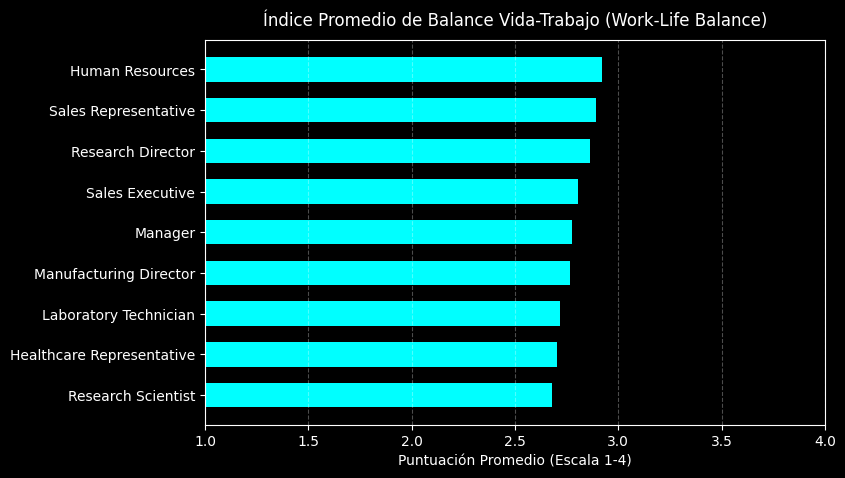

In [56]:
# KPI 3: Cálculo matemático
kpi_3 = df.groupby('JobRole')['WorkLifeBalance'].mean().sort_values(ascending=True).reset_index()
kpi_3.columns = ['Rol Operativo', 'Índice WLB Promedio']

print(f"{' ÍNDICE WORK-LIFE BALANCE (ESCALA 1-4) ':^55}")
print("-" * 55)
for _, fila in kpi_3.iterrows():
    print(f"- {fila['Rol Operativo']:<30}   {fila['Índice WLB Promedio']:.2f}  ")
print("-" * 55)

#KPI 3: Indice de balance Vida-Trabajo
print("-" * 80)
balance_cargo = df.groupby('JobRole')['WorkLifeBalance'].mean().sort_values()
plt.figure(figsize=(8, 5))
plt.barh(balance_cargo.index, balance_cargo.values, color='cyan', height=0.6)
plt.title('Índice Promedio de Balance Vida-Trabajo (Work-Life Balance)', fontsize=12, pad=10)
plt.xlabel('Puntuación Promedio (Escala 1-4)')
plt.xlim(1.0, 4.0)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

### Conclusión KPI 3: Índice de Balance Vida-Trabajo por Cargo
* El rol de Recursos Humanos lidera el indicador con una puntuación de 2.92 sobre 4, mientras que los Científicos de Investigación (Research Scientist) presentan el nivel más crítico con 2.68, identificado la calidad del ambiente laboral y los riesgos de burnout.

      DIAGNÓSTICO DE FLUIDEZ DE CARRERA (ACTIVOS)      
Años promedio en el Puesto Actual:        4.48 años
Años promedio desde última Promoción:    2.23 años
-------------------------------------------------------
BRECHA NETA DE ESTANCAMIENTO:             2.25 años
--------------------------------------------------------------------------------


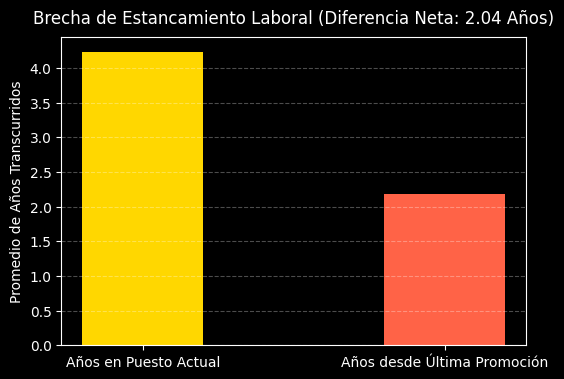

In [57]:
# KPI 4: Brecha de estancamiento Laboral
# Filtrar por colaboradores activos primero
activos = df[df['Attrition'] == 'No']

promedio_puesto = activos['YearsInCurrentRole'].mean()
promedio_promocion = activos['YearsSinceLastPromotion'].mean()
brecha_neta = promedio_puesto - promedio_promocion

print(f"{' DIAGNÓSTICO DE FLUIDEZ DE CARRERA (ACTIVOS) ':^55}")
print("=" * 55)
print(f"Años promedio en el Puesto Actual:      {promedio_puesto:>6.2f} años")
print(f"Años promedio desde última Promoción:  {promedio_promocion:>6.2f} años")
print("-" * 55)
print(f"BRECHA NETA DE ESTANCAMIENTO:           {brecha_neta:>6.2f} años")
print("=" * 55)
# KPI 4: Brecha de estancamiento laboral
print("-" * 80)
promedio_rol = df['YearsInCurrentRole'].mean()
promedio_promo = df['YearsSinceLastPromotion'].mean()

plt.figure(figsize=(6, 4))
plt.bar(['Años en Puesto Actual', 'Años desde Última Promoción'], [promedio_rol, promedio_promo], color=['gold', 'tomato'], width=0.4)
plt.title(f'Brecha de Estancamiento Laboral (Diferencia Neta: {promedio_rol - promedio_promo:.2f} Años)', fontsize=12, pad=10)
plt.ylabel('Promedio de Años Transcurridos')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

### Conclusión KPI 4: Brecha de Estancamiento Laboral
* Existe una brecha de estancamiento neta de 2.25
 años (los colaboradores promedian 4.48 años continuos en su puesto actual frente a solo 2.23 años transcurridos desde su último ascenso), indicador expone fallas en la fluidez de las líneas de carrera. Este estancamiento operativo se vincula directamente con la caída en la productividad y la pérdida de motivación laboral.
